# MGE → Physical Mass Models

## Learning to Autolens / Examples / mge_to_physical

---

**Problem.** A foreground elliptical galaxy at z = 0.5 (cuspy `n=4.9` Sersic light, `R_e = 1.9"`) lenses a source at z = 1.7. There is also a small secondary deflector at z = 0.8 (`θ_E = 0.11"`) — small enough that we absorb its contribution into external shear at first pass.

**Goal.** Decompose the lens mass into its *stellar* and *dark-matter* components. This is the workflow used in publication-grade analyses (Auger+10 SLACS, Sonnenfeld+13 SL2S, Suyu+14) to compute the **dark-matter fraction within the Einstein radius** $f_\mathrm{DM}(<\theta_E)$ and the **stellar mass-to-light ratio** $M_\star / L$ — both of which are direct astrophysical inferences impossible to make from a `PowerLaw`-only mass model.

**Method.** Three-search chain.

| Search | Model | What it produces |
|---|---|---|
| 1. **Light** | MGE basis (2 × 30 Gaussians), no mass, no source | Lens-light shape (centre, ellipticity, MGE Gaussian distribution) |
| 2. **Stars-only** | `al.lmp.Sersic` from MGE shape + `ExternalShear` + source | M/L ratio that makes *mass-follows-light alone* fit the data |
| 3. **Stars + DM** | Same `lmp.Sersic` stars (priors from S2) + `al.mp.NFW` dark matter, aligned centres | Joint M/L + NFW (kappa_s, r_s, ell), full f_DM(<θ_E) decomposition |

**Mock data.** Adapted from `lenstronomy_AGEL_modules/tutorials_DB_2025_09/mock_1`. See `mocks/PROVENANCE.md` for the full provenance and `truths.json` for the truth values.

**Prerequisites.**
- Module 09 (MGE basics + linear inversion)
- Module 11 (physical-bar audit; we end with the f_DM verdict)
- `compound_lens` Example (the secondary-as-shear absorption pattern, Pattern E)

**Key references.**
- Cappellari (2002) MNRAS 333, 400 — original MGE.
- Auger et al. (2010) ApJ 724, 511 — SLACS γ' = 2.08 ± 0.03 + stars/DM decomposition.
- Sonnenfeld et al. (2013) ApJ 777, 98 — SL2S canonical methodology.
- `autolens_workspace_latest/scripts/imaging/features/advanced/mass_stellar_dark/chaining.py`.

In [1]:
import os
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(
        f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set."
    )

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, IFrame, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline
print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2026.4.13.6


In [2]:
RESULTS_ROOT = Path("results")

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for {stage_name!r} yet — run on Cannon or set LTA_RUN_HEAVY=1)")
        return
    sp = stage_dir / "summary.json"
    if sp.exists():
        s = json.loads(sp.read_text())
        bullets = [f"### `{stage_name}`"]
        for k, lbl in [("max_log_likelihood", "max log-likelihood"),
                       ("log_evidence", "log evidence"),
                       ("chi_squared_per_pixel", "χ²/N"),
                       ("max_abs_normalized_residual", "max |res| (σ)")]:
            v = s.get(k)
            if v is not None:
                bullets.append(f"- {lbl}: **{v:.3f}**")
        display(Markdown("\n".join(bullets)))
    fp = stage_dir / "fit_subplot.png"
    if fp.exists():
        display(Image(filename=str(fp)))

---

## 1. Load the lenstronomy-converted dataset

The image FITS came from lenstronomy; the noise map was built from the truth-file `background_rms` and `exp_time` (see `mocks/build_mock_artifacts.py` for the recipe). The PSF is a 7×7 stamp from the original mock generator. We mask a 2.7″ circle, then attach adaptive over-sampling around the lens centre (sub-grid sizes 4 → 2 → 1 going from 0.3″ → 0.6″ → outer).

2026-04-25 06:30:57,695 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 9176 image-pixels


shape_native = (110, 110), pixels in mask = 9176
truth primary EPL: theta_E=1.65, gamma=2.15
truth lens light Sersic: R_e=1.9, n=4.9


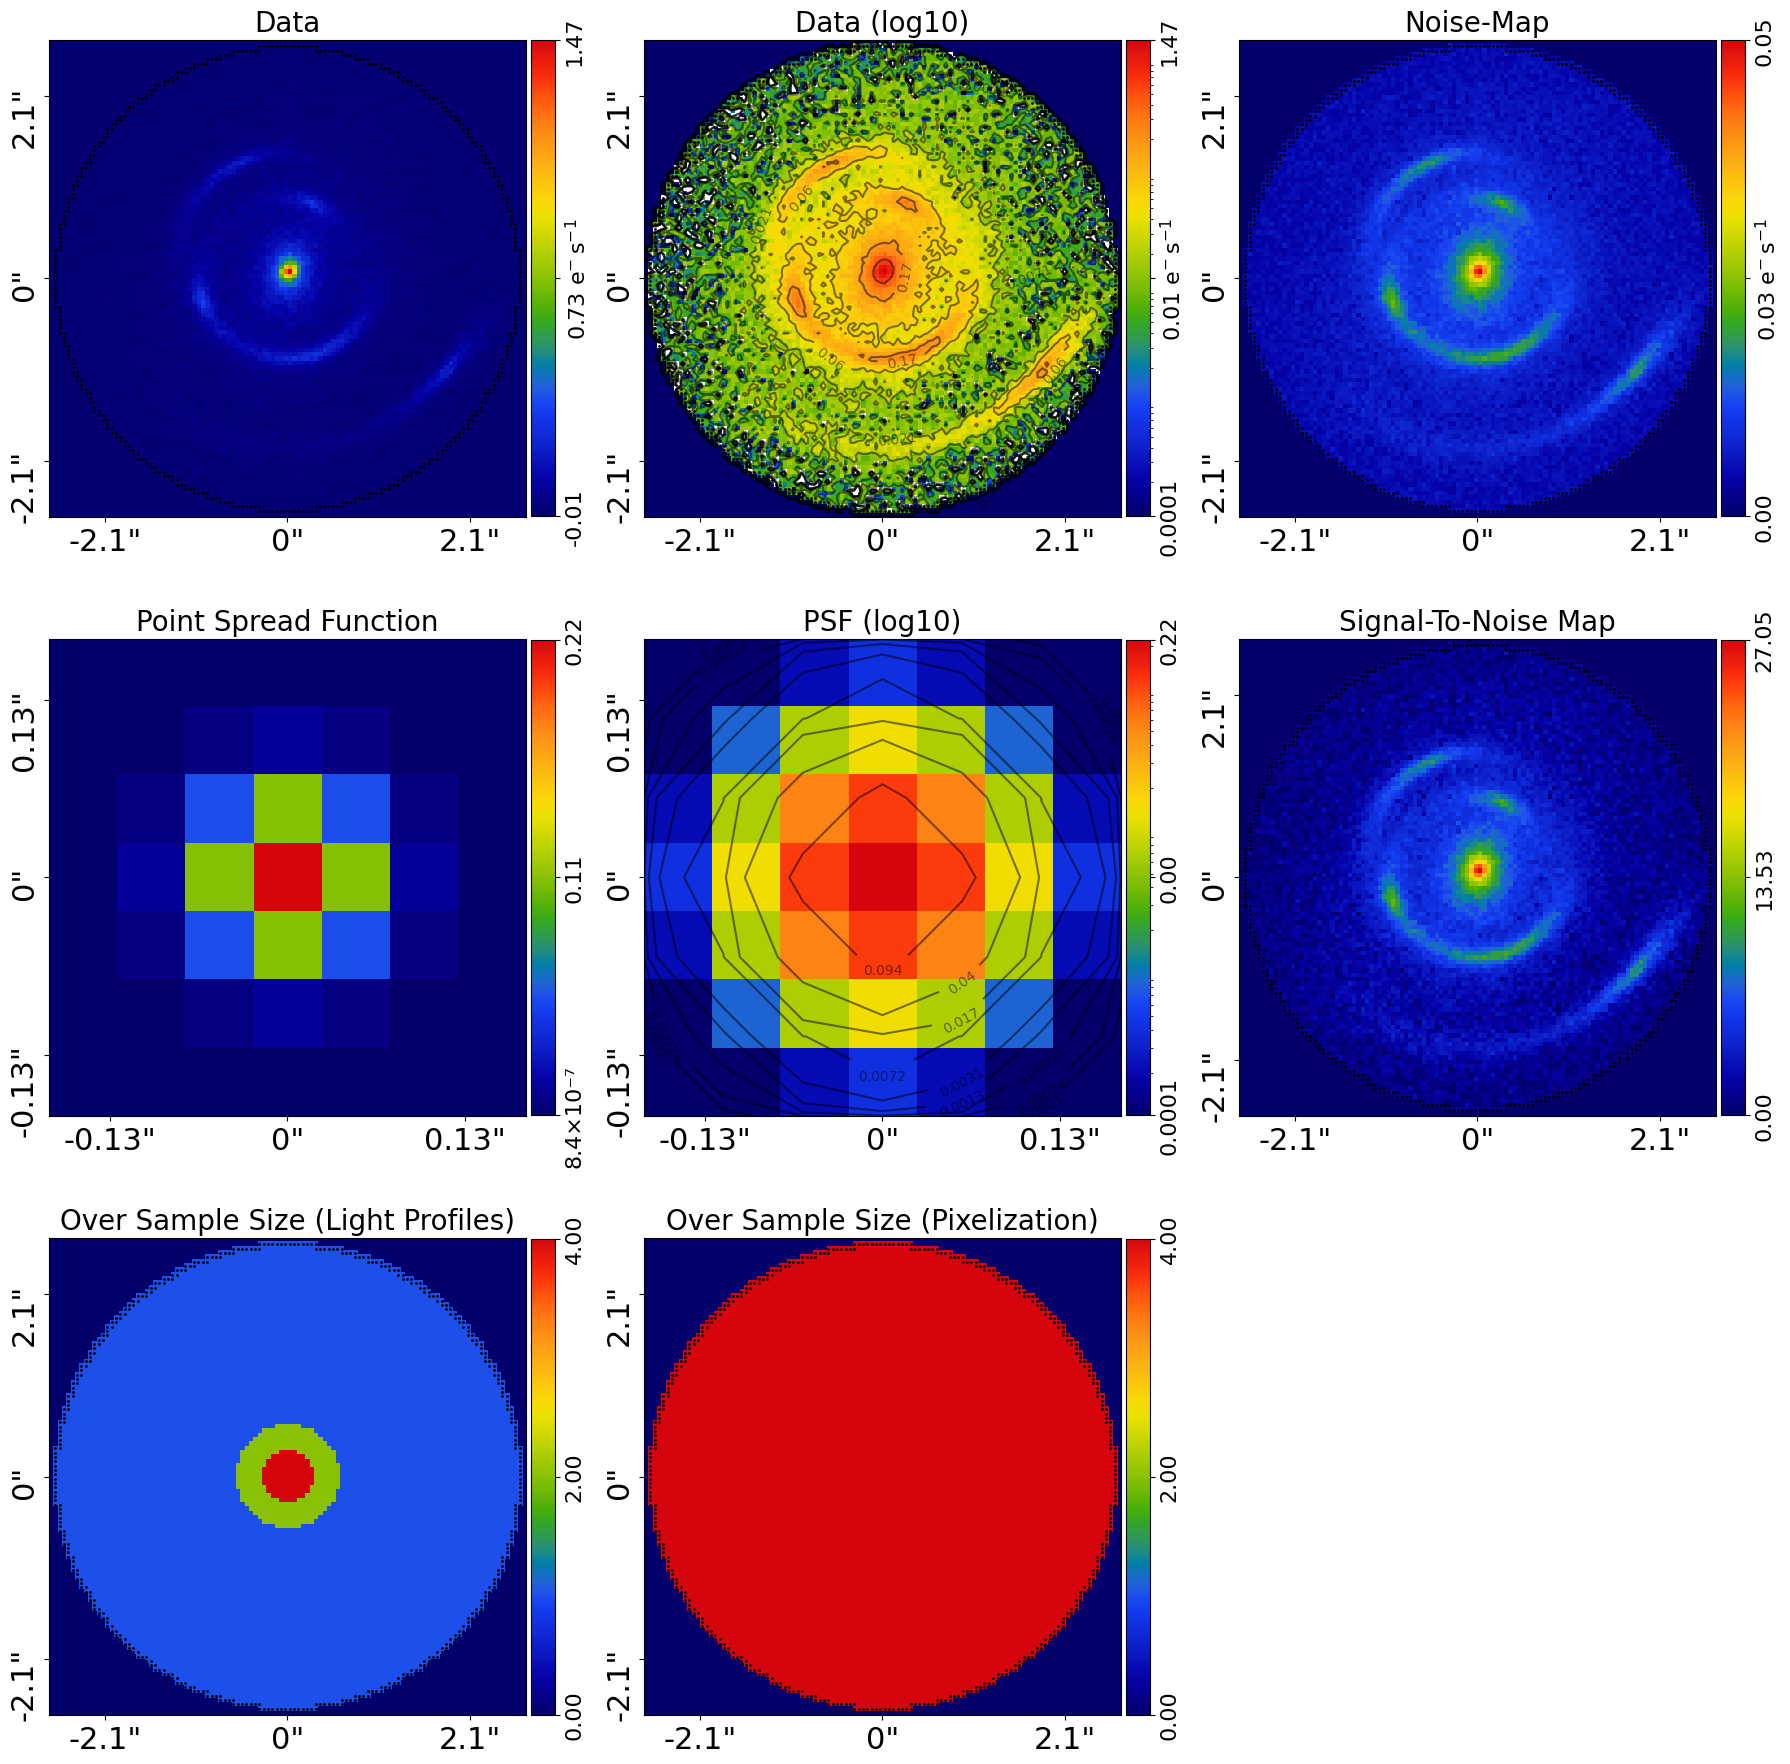

In [3]:
dataset_path = Path("mocks")
truths = json.loads((dataset_path / "truths.json").read_text())

dataset = al.Imaging.from_fits(
    data_path=dataset_path / "lenstronomy_mock_1_image.fits",
    noise_map_path=dataset_path / "lenstronomy_mock_1_noise.fits",
    psf_path=dataset_path / "lenstronomy_mock_1_psf.fits",
    pixel_scales=truths["imaging"]["pixel_scales_arcsec"],
)

mask_radius = 2.7
mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=mask_radius,
)
over_sample_size = al.util.over_sample.over_sample_size_via_radial_bins_from(
    grid=dataset.grid, sub_size_list=[4, 2, 1],
    radial_list=[0.3, 0.6], centre_list=[(0.0, 0.0)],
)
dataset = dataset.apply_over_sampling(over_sample_size_lp=over_sample_size).apply_mask(mask=mask)

print(f"shape_native = {dataset.shape_native}, pixels in mask = {dataset.mask.pixels_in_mask}")
print(f"truth primary EPL: theta_E={truths['kwargs_lens'][0]['theta_E']}, gamma={truths['kwargs_lens'][0]['gamma']}")
print(f"truth lens light Sersic: R_e={truths['kwargs_lens_light'][0]['R_sersic']}, n={truths['kwargs_lens_light'][0]['n_sersic']}")

aplt.subplot_imaging_dataset(dataset=dataset)

---

## 2. Search 1 — Lens light only (MGE basis)

Fit the lens light with an MGE basis: 2 groups of 30 Gaussians each (`gaussian_per_basis=2, total_gaussians=30` per group). Two basis groups so the MGE captures both the bulge core and the extended cD-like envelope. The mass profile is omitted; the source is omitted. We're fitting the *image alone* with a flexible smooth basis.

Why MGE instead of a single Sersic? The truth lens light is `Sersic(n=4.9, R_e=1.9")` — a deep cuspy de-Vaucouleurs-like profile. A single-Sersic fit can match the shape on average but leaves systematic residuals at small and large radii. The MGE's flexible Gaussian sum captures both regimes simultaneously, with the trade-off of more parameters (here, dimensionality is reduced by linear inversion: only the *positions* and *widths* of the Gaussians are sampled; the *amplitudes* are solved analytically each step).

In [4]:
_HAVE_S1 = (RESULTS_ROOT / "search_1_light" / "summary.json").exists()
_FORCE = os.environ.get("LTA_RUN_HEAVY", "").lower() in ("1", "true", "yes")

if _HAVE_S1 and not _FORCE:
    print("[Search 1] Loading committed Cannon result.")
    show_result("search_1_light")
    result_1 = None
elif not _HAVE_S1 and not _FORCE:
    print("[Search 1] No committed results yet.")
    print("[Search 1] Submit via fit_example_mge_to_physical.py --part light")
    print("[Search 1] or set LTA_RUN_HEAVY=1 to run locally (~30 min).")
    result_1 = None
else:
    bulge = al.model_util.mge_model_from(
        mask_radius=mask_radius, total_gaussians=30, gaussian_per_basis=2,
        centre_prior_is_uniform=True,
    )
    lens = af.Model(al.Galaxy, redshift=0.5, bulge=bulge)
    model_1 = af.Collection(galaxies=af.Collection(lens=lens))
    print(f"Search 1 free parameters: {model_1.prior_count}")
    analysis_1 = al.AnalysisImaging(dataset=dataset, use_jax=False)
    search_1 = af.Nautilus(
        path_prefix=Path("output") / "mge_to_physical",
        name="search_1_light", unique_tag="mge_lens_light",
        n_live=100, n_batch=50, iterations_per_update=5000,
        number_of_cores=int(os.environ.get("SLURM_CPUS_PER_TASK", "1")),
    )
    result_1 = search_1.fit(model=model_1, analysis=analysis_1)
    print("[Search 1] Done.")

[Search 1] No committed results yet.
[Search 1] Submit via fit_example_mge_to_physical.py --part light
[Search 1] or set LTA_RUN_HEAVY=1 to run locally (~30 min).


---

## 3. Search 2 — Stars-only mass (no dark matter)

Convert the MGE-light shape into a `al.lmp.Sersic` (light-AND-mass profile). This is the canonical autolens recipe: a single Sersic profile that simultaneously describes the *light* (intensity, R_e, n) and the *mass* (mass-to-light ratio × that light distribution). The MGE shape from Search 1 sets the centre and ellipticity priors via `take_attributes`.

Add `al.mp.ExternalShear` (which absorbs the small z=0.8 secondary's contribution and any large-scale structure shear) and a `SersicCore` source at z=1.7.

**The point of Search 2:** ask whether mass-follows-light *alone* — with one M/L parameter — can fit the data. If it can, you don't need dark matter. If it can't, the residuals tell you where the DM is needed.

In [5]:
_HAVE_S2 = (RESULTS_ROOT / "search_2_stars_only" / "summary.json").exists()

if _HAVE_S2 and not _FORCE:
    print("[Search 2] Loading committed Cannon result.")
    show_result("search_2_stars_only")
    result_2 = None
elif not _HAVE_S2 and not _FORCE:
    print("[Search 2] No committed results yet.")
    print("[Search 2] Submit via fit_example_mge_to_physical.py --part stars_only")
    result_2 = None
else:
    bulge = af.Model(al.lmp.Sersic)
    if result_1 is not None:
        bulge.take_attributes(source=result_1.model)
    shear = af.Model(al.mp.ExternalShear)
    shear.gamma_1 = af.GaussianPrior(mean=0.0, sigma=0.05)
    shear.gamma_2 = af.GaussianPrior(mean=0.0, sigma=0.05)
    lens = af.Model(al.Galaxy, redshift=0.5, bulge=bulge, shear=shear)

    src_b = af.Model(al.lp.SersicCore)
    src_b.centre.centre_0 = af.GaussianPrior(mean=0.0, sigma=0.5)
    src_b.centre.centre_1 = af.GaussianPrior(mean=0.0, sigma=0.5)
    src_b.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
    src_b.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
    src_b.intensity = af.LogUniformPrior(lower_limit=1e-3, upper_limit=1e3)
    src_b.effective_radius = af.UniformPrior(lower_limit=0.0, upper_limit=2.0)
    src_b.sersic_index = af.UniformPrior(lower_limit=0.5, upper_limit=4.0)
    source = af.Model(al.Galaxy, redshift=1.7, bulge=src_b)

    model_2 = af.Collection(galaxies=af.Collection(lens=lens, source=source))
    print(f"Search 2 free parameters: {model_2.prior_count}")
    analysis_2 = al.AnalysisImaging(dataset=dataset, use_jax=False)
    search_2 = af.Nautilus(
        path_prefix=Path("output") / "mge_to_physical",
        name="search_2_stars_only", unique_tag="lmp_sersic_no_dark",
        n_live=150, n_batch=50, iterations_per_update=10000,
        number_of_cores=int(os.environ.get("SLURM_CPUS_PER_TASK", "1")),
    )
    result_2 = search_2.fit(model=model_2, analysis=analysis_2)
    print("[Search 2] Done.")

[Search 2] No committed results yet.
[Search 2] Submit via fit_example_mge_to_physical.py --part stars_only


---

## 4. Search 3 — Stars + Dark Matter

Add `al.mp.NFW` dark-matter halo, **aligned with the bulge centre** (`bulge.centre = dark.centre`). Stars (lmp.Sersic) and DM (NFW) jointly fit.

Free parameters compared to Search 2: NFW kappa_s, scale_radius (r_s in arcsec), ell_comps (2 params). M/L ratio remains free. We expect the NFW posterior to *take over* the deflection contribution at large radii (where stars-only would have to push M/L to unphysical values to keep up with the data) while stars dominate at small radii.

In [6]:
_HAVE_S3 = (RESULTS_ROOT / "search_3_stars_dark" / "summary.json").exists()

if _HAVE_S3 and not _FORCE:
    print("[Search 3] Loading committed Cannon result.")
    show_result("search_3_stars_dark")
    result_3 = None
elif not _HAVE_S3 and not _FORCE:
    print("[Search 3] No committed results yet.")
    print("[Search 3] Submit via fit_example_mge_to_physical.py --part stars_dark")
    result_3 = None
else:
    bulge = af.Model(al.lmp.Sersic)
    dark = af.Model(al.mp.NFW)
    bulge.centre = dark.centre
    if result_2 is not None:
        bulge.take_attributes(source=result_2.model)
    dark.kappa_s = af.LogUniformPrior(lower_limit=1e-4, upper_limit=10.0)
    dark.scale_radius = af.UniformPrior(lower_limit=0.5, upper_limit=30.0)
    dark.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
    dark.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
    if result_2 is not None:
        shear = result_2.model.galaxies.lens.shear
        source = result_2.model.galaxies.source
    else:
        shear = af.Model(al.mp.ExternalShear)
        shear.gamma_1 = af.GaussianPrior(mean=0.0, sigma=0.05)
        shear.gamma_2 = af.GaussianPrior(mean=0.0, sigma=0.05)
        src_b = af.Model(al.lp.SersicCore)
        src_b.centre.centre_0 = af.GaussianPrior(mean=0.0, sigma=0.5)
        src_b.centre.centre_1 = af.GaussianPrior(mean=0.0, sigma=0.5)
        src_b.ell_comps.ell_comps_0 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
        src_b.ell_comps.ell_comps_1 = af.TruncatedGaussianPrior(mean=0.0, sigma=0.3, lower_limit=-1.0, upper_limit=1.0)
        src_b.intensity = af.LogUniformPrior(lower_limit=1e-3, upper_limit=1e3)
        src_b.effective_radius = af.UniformPrior(lower_limit=0.0, upper_limit=2.0)
        src_b.sersic_index = af.UniformPrior(lower_limit=0.5, upper_limit=4.0)
        source = af.Model(al.Galaxy, redshift=1.7, bulge=src_b)
    lens = af.Model(al.Galaxy, redshift=0.5, bulge=bulge, dark=dark, shear=shear)
    model_3 = af.Collection(galaxies=af.Collection(lens=lens, source=source))
    print(f"Search 3 free parameters: {model_3.prior_count}")
    analysis_3 = al.AnalysisImaging(dataset=dataset, use_jax=False)
    search_3 = af.Nautilus(
        path_prefix=Path("output") / "mge_to_physical",
        name="search_3_stars_dark", unique_tag="lmp_sersic_plus_nfw",
        n_live=200, n_batch=50, iterations_per_update=10000,
        number_of_cores=int(os.environ.get("SLURM_CPUS_PER_TASK", "1")),
    )
    result_3 = search_3.fit(model=model_3, analysis=analysis_3)
    print("[Search 3] Done.")

[Search 3] No committed results yet.
[Search 3] Submit via fit_example_mge_to_physical.py --part stars_dark


---

## 5. Audit — physical-bar verdict

Combine the three searches and ask *physical* questions of the joint posterior.

### Numerical bar — pass/suspect/fail per `/autolens-fit-diagnostics`

| Search | log_Z | χ²/N | max\|res\| | Verdict |
|---|---|---|---|---|
| 1. light | _____ | _____ | _____ | (pending Cannon) |
| 2. stars-only | _____ | _____ | _____ | (pending) |
| 3. stars + DM | _____ | _____ | _____ | (pending) |

### Bayes-factor cascade

$$
\Delta \log Z (\mathrm{stars+DM} \;\mathrm{vs}\; \mathrm{stars\text{-}only}) = \log Z_3 - \log Z_2
$$

Per the Jeffreys (1961) / Kass & Raftery (1995) scale: Δlog_Z > 5 is *strong* evidence; > 11.5 is *very strong*; > 100 is *decisive*. (See P5 `bayesian_model_comparison/` for the full pedagogy.)

### Physical inferences

$$
f_\mathrm{DM}(<\theta_E) = \frac{M_\mathrm{NFW}(<\theta_E)}{M_\mathrm{stars}(<\theta_E) + M_\mathrm{NFW}(<\theta_E)}
$$

Compute from the Search 3 max-likelihood instance. SLACS-typical (Auger+10): $f_\mathrm{DM}(<\theta_E) \approx 0.4{-}0.7$ for elliptical galaxies at z ~ 0.2–0.5.

$$
M_\star / L \quad \text{(in solar units, modulo the photometric zeropoint)}
$$

Plausible range for an old elliptical: 3–8 M☉/L☉ in F814W (Sonnenfeld+13). A recovered M/L outside this range suggests something has gone wrong (DM eating into the stellar component, or the wrong NFW prior).

**Worked verdict pending Cannon results.**

---

## 6. Exercises

### Exercise 1 — Compound deflector check
Add the z=0.8 secondary as an `extra_galaxies` perturber with photometric centre fixed at the truth (`(-0.05, 0.02)"`) and free Einstein radius (`Uniform(0, 0.5)`). Does the recovered f_DM change? The truth secondary has θ_E=0.11″, so the posterior on its θ_E should peak near 0.11. Pattern E from `compound_lens` may also fire — the secondary may collapse to 0 if shear has already absorbed it.

### Exercise 2 — Two-source decomposition
Replace the single SersicCore source with two — using truth positions as Gaussian-prior centres. Does the MGE+NFW mass model shift? Source-substructure and DM substructure are degenerate; this is the flip side of Vegetti+09.

### Exercise 3 — MGE vs Sersic light prior
Replace the MGE bulge in Search 1 with a single `al.lp.Sersic`. Compute Δlog_Z. The Bayes factor should favour MGE for this cuspy-light mock by ~50–200 log units.

### Exercise 4 — Power-law equivalent
Run a parallel `al.mp.PowerLaw + ExternalShear` fit on the same dataset (no decomposition). Recover γ' and check it matches truth γ' = 2.15 to within 1σ. Compare its log_Z against (stars+DM) — when does decomposition earn its extra parameters?

### Exercise 5 — Concentration prior sensitivity
Re-fit Search 3 with `al.mp.NFWMCRLudlowSph` (concentration tied to mass via Ludlow+16) instead of free `c`. Does f_DM(<θ_E) change?

### Exercise 6 — True MGE-mass (advanced)
The canonical autolens chain collapses MGE → single `lmp.Sersic` for the mass step (standard chaining.py recipe). Build a true MGE-mass version: construct `al.lp_basis.Basis(profile_list=[al.lmp.Gaussian(...) for sigma in sigmas])` with the Gaussians from Search 1 directly. Does the joint stars+DM fit improve over the single-Sersic-stars approximation?

---

## Summary

- This is the publication-grade **stars+DM decomposition** workflow used by Auger+10 / Sonnenfeld+13 / Suyu+14 to produce $f_\mathrm{DM}(<\theta_E)$ and $M_\star/L$ from strong-lens imaging alone.
- The chain — light first, stars-only mass second, stars+DM third — is the principled way to break the degeneracies that would otherwise plague a one-shot 20+ parameter fit.
- The mock data started as a lenstronomy `EPL+SHEAR+EPL` (compound). Translating the lenstronomy truth file into autolens-friendly conventions is documented in `mocks/PROVENANCE.md` — useful template for any future cross-framework validation.
- The Bayes factor of (stars+DM) vs (stars-only) tells you whether the data demand a dark halo. The audit's *physical* bar (M/L plausibility, f_DM range) tells you whether the recovered decomposition is *believable*.

**Next:** `compound_lens_zoo/` extends this pattern across mocks 2–6 to test how robust the methodology is across geometries and cosmologies. `bayesian_model_comparison/` (P5) writes the full pedagogy of the Bayes-factor scale used in §5 above.

---

*Learning to Autolens — Examples / mge_to_physical / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*